In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [2]:
column_names = [
    "Country Name", "Time", "Exports of goods and services (% of GDP)",
    "Imports of goods and services (% of GDP)", "GDP (current US$)",
    "Population, total", "Foreign direct investment, net inflows (% of GDP)",
    "General government final consumption expenditure (% of GDP)",
    "Oil rents (% of GDP)", "Official exchange rate"
]


In [3]:
df = pd.read_csv('Data.csv', skiprows=52, header=None, names=column_names)

In [4]:
gdp_column = 'GDP (current US$)'
columns_to_drop = ["Country Name", "Time"]
df.drop(columns=columns_to_drop, inplace=True)

In [5]:
# Replace ".." with NaN
df = df.replace("..", pd.NA)

# Convert all remaining object columns to numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# --- Step 4: Drop Rows with ANY Null Values ---
print(f"Shape before dropping any nulls: {df.shape}")

# Drop any row that contains at least one null value in any column
df.dropna(inplace=True)

print(f"Shape after dropping all nulls:  {df.shape}")

Shape before dropping any nulls: (2914, 8)
Shape after dropping all nulls:  (2910, 8)


In [6]:
# Create the new target variable ('GDP in Billions') and drop the original
billion = 1_000_000_000
df['GDP in Billions'] = df[gdp_column] / billion
df.drop(columns=[gdp_column], inplace=True)

df.shape

(2910, 8)

In [7]:
gdp_column = 'GDP in Billions'

max_gdp = df[gdp_column].max()
min_gdp = df[gdp_column].min()

print(f"Maximum GDP: {max_gdp}")
print(f"Minimum GDP: {min_gdp}")

Maximum GDP: 23700.0
Minimum GDP: 0.3511365796


--- Correlation Matrix (without Country Name and Time) ---
                                                    Exports of goods and services (% of GDP)  \
Exports of goods and services (% of GDP)                                            1.000000   
Imports of goods and services (% of GDP)                                            0.864705   
Population, total                                                                  -0.188591   
Foreign direct investment, net inflows (% of GDP)                                   0.217819   
General government final consumption expenditur...                                  0.136297   
Oil rents (% of GDP)                                                                0.147984   
Official exchange rate                                                             -0.007956   
GDP in Billions                                                                    -0.163955   

                                                    Imports of goods and ser

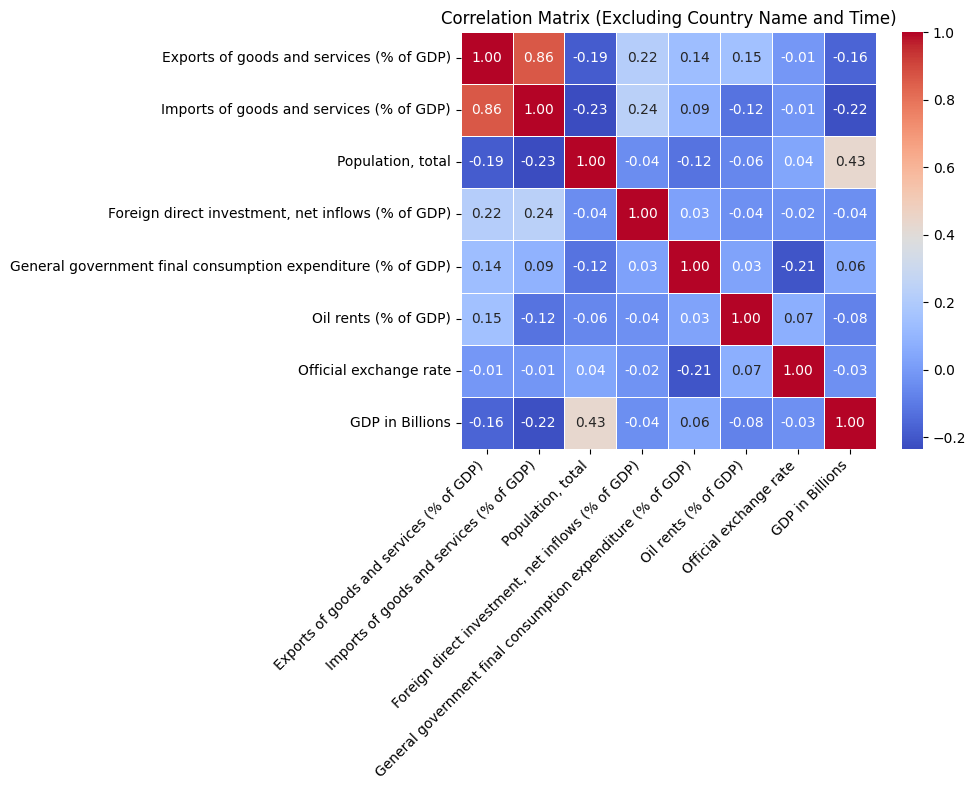

In [8]:
# --- Calculate the Correlation Matrix ---
# This line was missing from your original code
correlation_matrix = df.corr()


# --- Print and Visualize the Correlation Matrix ---
print("--- Correlation Matrix (without Country Name and Time) ---")
print(correlation_matrix)
print("\n" + "="*50 + "\n")

# --- Visualize the Correlation Matrix ---
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix (Excluding Country Name and Time)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Save the plot to a file
output_filename = 'correlation_heatmap.png'
plt.savefig(output_filename)

# To display the plot in the notebook
plt.show()

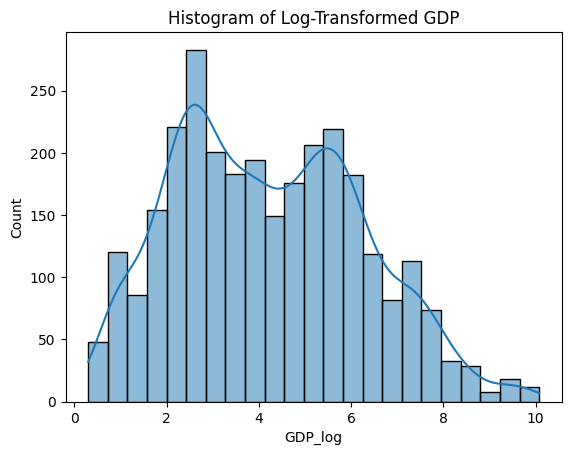

In [9]:
# Apply log transformation to the target variable
df['GDP_log'] = np.log1p(df['GDP in Billions'])

# You can now drop the original 'GDP in Billions' column
df.drop(columns=['GDP in Billions'], inplace=True)

# Let's visualize the new target variable
sns.histplot(df['GDP_log'], kde=True)
plt.title('Histogram of Log-Transformed GDP')
plt.show()

In [10]:



# 1. Define your features (X) and target (y)
# Your target is now the log-transformed GDP
y = df['GDP_log']
X = df.drop(columns=['GDP_log']) # Use all other columns as features

# 2. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")

Shape of X_train: (2328, 7)
Shape of X_test: (582, 7)


In [11]:
# Initialize the models
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)

# Train the Random Forest model
print("Training Random Forest...")
rf_model.fit(X_train, y_train)
print("Done.")

# Train the Gradient Boosting model
print("\nTraining Gradient Boosting...")
gb_model.fit(X_train, y_train)
print("Done.")

Training Random Forest...
Done.

Training Gradient Boosting...
Done.


In [13]:
# Make predictions on the test set
y_pred_rf_log = rf_model.predict(X_test)
y_pred_gb_log = gb_model.predict(X_test)

# --- IMPORTANT: Convert predictions back from log scale ---
y_pred_rf = np.expm1(y_pred_rf_log)
y_test_orig = np.expm1(y_test) # Also convert the true values back for comparison

# Evaluate the Random Forest model
print("--- Random Forest Evaluation ---")
rf_r2 = r2_score(y_test_orig, y_pred_rf)
rf_mae = mean_absolute_error(y_test_orig, y_pred_rf)
print(f"R-squared (R²): {rf_r2:.4f}")
print(f"Mean Absolute Error (MAE): {rf_mae:.4f} (in Billions of USD)")

# You can do the same for the Gradient Boosting model
y_pred_gb = np.expm1(y_pred_gb_log)
print("\n--- Gradient Boosting Evaluation ---")
gb_r2 = r2_score(y_test_orig, y_pred_gb)
gb_mae = mean_absolute_error(y_test_orig, y_pred_gb)
print(f"R-squared (R²): {gb_r2:.4f}")
print(f"Mean Absolute Error (MAE): {gb_mae:.4f} (in Billions of USD)")

--- Random Forest Evaluation ---
R-squared (R²): 0.9758
Mean Absolute Error (MAE): 71.9520 (in Billions of USD)

--- Gradient Boosting Evaluation ---
R-squared (R²): 0.8931
Mean Absolute Error (MAE): 176.1611 (in Billions of USD)


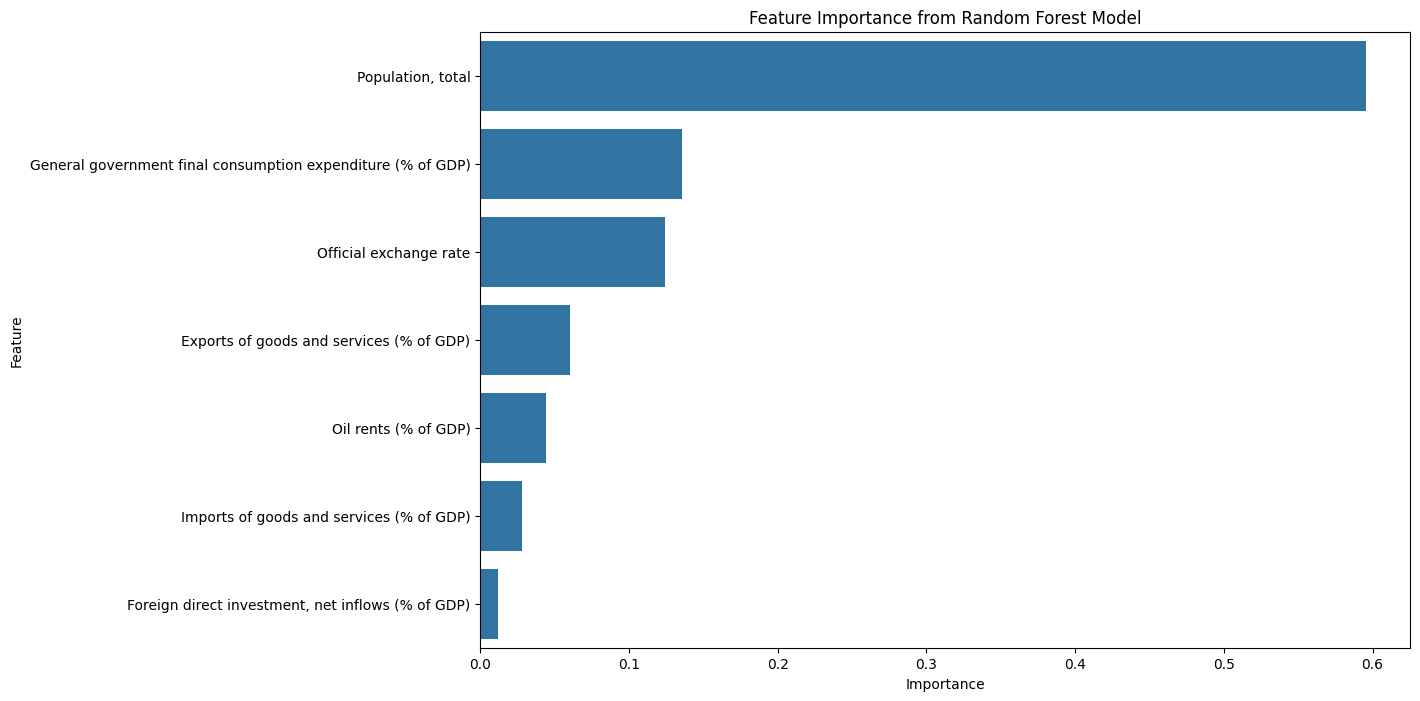

                                             Feature  Importance
2                                  Population, total    0.595523
4  General government final consumption expenditu...    0.135481
6                             Official exchange rate    0.124198
0           Exports of goods and services (% of GDP)    0.060312
5                               Oil rents (% of GDP)    0.044518
1           Imports of goods and services (% of GDP)    0.027944
3  Foreign direct investment, net inflows (% of GDP)    0.012025


In [14]:
# Get feature importances from the trained Random Forest model
importances = rf_model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for easier visualization
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Sort the features by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance from Random Forest Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

# Display the top features
print(feature_importance_df)


In [15]:

# 3. MANUAL INPUT AND PREDICTION SECTION

# --- You can change these values below ---
# I have pre-filled this with the values from the first row of the cleaned dataset (Albania, 1996)
# to provide a working example.
manual_input = {
    'Exports of goods and services (% of GDP)': 35.79945965,
    'Imports of goods and services (% of GDP)': 28.33607573,
    'Population, total': 5107790.0,
    'Foreign direct investment, net inflows (% of GDP)': 1.082131505,
    'General government final consumption expenditure (% of GDP)': 21.91581855,
    'Oil rents (% of GDP)':0,
    'Official exchange rate': 4.366666667
}

# This is the actual GDP value (in billions) for the row used in manual_input
actual_gdp_billions = 134

# Convert the manual input dictionary into a DataFrame for the model
input_df = pd.DataFrame([manual_input])

# --- Prediction and Error Calculation ---
# The model predicts on the log scale
predicted_gdp_log = rf_model.predict(input_df)[0]

# IMPORTANT: Convert the prediction back from log scale to billions
predicted_gdp_billions = np.expm1(predicted_gdp_log)

# Calculate the error
absolute_error = abs(predicted_gdp_billions - actual_gdp_billions)
percentage_error = (absolute_error / actual_gdp_billions) * 100

# 4. DISPLAY THE RESULTS

print("--- Manual Input Analysis ---")
print("\nInput Features:")
print(input_df.to_string(index=False))
print("\n--- Comparison ---")
print(f"Actual GDP:       ${actual_gdp_billions:.4f} Billion")
print(f"Predicted GDP:    ${predicted_gdp_billions:.4f} Billion")
print("\n--- Error Calculation ---")
print(f"Absolute Error:   ${absolute_error:.4f} Billion")
print(f"Percentage Error: {percentage_error:.2f}%")


--- Manual Input Analysis ---

Input Features:
 Exports of goods and services (% of GDP)  Imports of goods and services (% of GDP)  Population, total  Foreign direct investment, net inflows (% of GDP)  General government final consumption expenditure (% of GDP)  Oil rents (% of GDP)  Official exchange rate
                                 35.79946                                 28.336076          5107790.0                                           1.082132                                                    21.915819                     0                4.366667

--- Comparison ---
Actual GDP:       $134.0000 Billion
Predicted GDP:    $137.1349 Billion

--- Error Calculation ---
Absolute Error:   $3.1349 Billion
Percentage Error: 2.34%


In [16]:
# Import RandomizedSearchCV if you haven't already
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import numpy as np

# --- 1. Define the Hyperparameter Grids ---
# These are the ranges of settings we want to test for each model.

# Parameters for Random Forest
rf_param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'] 
}

# Parameters for Gradient Boosting
gb_param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 8, 10],
    'subsample': [0.7, 0.8, 0.9],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# --- 2. Set Up and Run Randomized Search for Random Forest ---
print("--- Starting hyperparameter tuning for Random Forest... ---")
rf = RandomForestRegressor(random_state=42)

rf_random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_param_dist,
    n_iter=50,  # Number of parameter combinations to try
    cv=5,       # 5-fold cross-validation
    random_state=42,
    n_jobs=-1,  # Use all available CPU cores
    verbose=1   # Shows progress
)

# Fit the model (This will take some time)
# It's fitting on the log-transformed target variable, y_train
rf_random_search.fit(X_train, y_train)

# Get the best model
best_rf_model = rf_random_search.best_estimator_
print(f"\nBest Random Forest Parameters Found: {rf_random_search.best_params_}")


# --- 3. Set Up and Run Randomized Search for Gradient Boosting ---
print("\n--- Starting hyperparameter tuning for Gradient Boosting... ---")
gb = GradientBoostingRegressor(random_state=42)

gb_random_search = RandomizedSearchCV(
    estimator=gb,
    param_distributions=gb_param_dist,
    n_iter=50,
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Fit the model (This will also take time)
gb_random_search.fit(X_train, y_train)

# Get the best model
best_gb_model = gb_random_search.best_estimator_
print(f"\nBest Gradient Boosting Parameters Found: {gb_random_search.best_params_}")


# --- 4. Evaluate the Final Tuned Models ---
print("\n--- Final Tuned Model Evaluation ---")

# a. Evaluate the tuned Random Forest model
y_pred_rf_log_tuned = best_rf_model.predict(X_test)
y_pred_rf_tuned = np.expm1(y_pred_rf_log_tuned) # Convert back from log scale
y_test_orig = np.expm1(y_test) # Original test values

rf_r2_tuned = r2_score(y_test_orig, y_pred_rf_tuned)
rf_mae_tuned = mean_absolute_error(y_test_orig, y_pred_rf_tuned)

print("\n--- Tuned Random Forest ---")
print(f"R-squared (R²): {rf_r2_tuned:.4f}")
print(f"Mean Absolute Error (MAE): {rf_mae_tuned:.4f} (in Billions of USD)")

# b. Evaluate the tuned Gradient Boosting model
y_pred_gb_log_tuned = best_gb_model.predict(X_test)
y_pred_gb_tuned = np.expm1(y_pred_gb_log_tuned) # Convert back from log scale

gb_r2_tuned = r2_score(y_test_orig, y_pred_gb_tuned)
gb_mae_tuned = mean_absolute_error(y_test_orig, y_pred_gb_tuned)

print("\n--- Tuned Gradient Boosting ---")
print(f"R-squared (R²): {gb_r2_tuned:.4f}")
print(f"Mean Absolute Error (MAE): {gb_mae_tuned:.4f} (in Billions of USD)")

--- Starting hyperparameter tuning for Random Forest... ---
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best Random Forest Parameters Found: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}

--- Starting hyperparameter tuning for Gradient Boosting... ---
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best Gradient Boosting Parameters Found: {'subsample': 0.7, 'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 8, 'learning_rate': 0.1}

--- Final Tuned Model Evaluation ---

--- Tuned Random Forest ---
R-squared (R²): 0.9598
Mean Absolute Error (MAE): 102.2615 (in Billions of USD)

--- Tuned Gradient Boosting ---
R-squared (R²): 0.9807
Mean Absolute Error (MAE): 63.9430 (in Billions of USD)


In [16]:
# Assuming 'rf_model' is your trained Random Forest model
import joblib

# Save the model to a file
joblib.dump(rf_model, 'random_forest_model.pkl')

print("Model saved successfully as random_forest_model.pkl")

Model saved successfully as random_forest_model.pkl


In [17]:
# app.py

import streamlit as st
import pandas as pd
import numpy as np
import joblib

# --- 1. LOAD THE SAVED MODEL ---
# Use a try-except block to handle the case where the model file doesn't exist.
try:
    model = joblib.load('random_forest_model.pkl')
except FileNotFoundError:
    st.error("Model file not found. Please make sure 'random_forest_model.pkl' is in the same directory.")
    st.stop() # Stop the app if the model can't be loaded

# --- 2. SET UP THE GUI INTERFACE ---
st.title('🌍 GDP Prediction Model')
st.write("Enter the country's metrics to predict its GDP in billions of US dollars.")

st.sidebar.header('Input Features')

# Create input fields in the sidebar for each feature
# The keys must match the feature names your model was trained on
exp_gdp = st.sidebar.number_input('Exports of goods and services (% of GDP)', value=35.8)
imp_gdp = st.sidebar.number_input('Imports of goods and services (% of GDP)', value=28.3)
population = st.sidebar.number_input('Population, total', value=5107790)
fdi = st.sidebar.number_input('Foreign direct investment, net inflows (% of GDP)', value=1.08)
gov_exp = st.sidebar.number_input('General government final consumption expenditure (% of GDP)', value=21.9)
oil_rent = st.sidebar.number_input('Oil rents (% of GDP)', value=0.0)
exchange_rate = st.sidebar.number_input('Official exchange rate', value=4.36)

# --- 3. PREDICTION LOGIC ---
# Create a button that will trigger the prediction
if st.sidebar.button('Predict GDP'):
    # a. Create a DataFrame from the user's input
    # The column order and names must be IDENTICAL to what the model was trained on
    feature_names = [
        'Exports of goods and services (% of GDP)',
        'Imports of goods and services (% of GDP)',
        'Population, total',
        'Foreign direct investment, net inflows (% of GDP)',
        'General government final consumption expenditure (% of GDP)',
        'Oil rents (% of GDP)',
        'Official exchange rate'
    ]
    
    input_data = pd.DataFrame([[
        exp_gdp, imp_gdp, population, fdi, gov_exp, oil_rent, exchange_rate
    ]], columns=feature_names)
    
    st.write('---')
    st.subheader('Input Data:')
    st.write(input_data)

    # b. Make a prediction (this will be on the log scale)
    predicted_gdp_log = model.predict(input_data)[0]

    # c. IMPORTANT: Reverse the log transformation to get the actual GDP value
    # You used np.log1p() in your notebook, so you must use np.expm1() to reverse it.
    predicted_gdp_billions = np.expm1(predicted_gdp_log)

    # d. Display the result
    st.subheader('Prediction Result:')
    st.success(f'The predicted GDP is **${predicted_gdp_billions:,.2f} Billion**')
    

2025-10-06 10:53:38.536 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-06 10:53:38.985 
  command:

    streamlit run C:\Users\safda\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2025-10-06 10:53:38.986 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-06 10:53:38.987 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-06 10:53:38.988 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-06 10:53:38.989 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-06 10:53:38.991 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-06 10:53: